# EDA Completo - Telecom Churn (Base Extended)

Este notebook cobre a Fase 1 do projeto: diagnosticar a base bruta e deixá-la pronta para os baselines iniciais.

Pergunta central: **a base extended esta pronta para treino de baseline depois do tratamento minimo necessario e sem leakage metodologico?**

0. Business Understanding
1. Carregamento e contexto da base
2. Qualidade estrutural dos dados
3. Distribuicao do target e sinais de churn na base bruta
4. Data readiness e risco de leakage
5. Tratamento da base para baseline
6. Split, imputacao e matriz final sem leakage
7. Validacao final da base preparada
8. Conclusao executiva

## 0) Business Understanding

### Problema de negocio

A operadora quer reduzir cancelamentos usando priorizacao de clientes com maior risco de churn.
A decisao pratica e: **quais clientes devem entrar primeiro nas campanhas de retencao para maximizar impacto e controlar custo?**

### Objetivo de negocio

- Reduzir churn na carteira ativa
- Preservar receita recorrente com foco em clientes de maior valor
- Melhorar eficiencia das campanhas, evitando contato em massa sem priorizacao

### Stakeholders

| Stakeholder | Papel |
|---|---|
| Marketing / CRM | Define regras de campanha e incentivo |
| Retencao / Atendimento | Executa abordagem dos clientes priorizados |
| BI / Analytics | Acompanha resultados operacionais e financeiros |
| Data Science / MLOps | Treina, monitora e atualiza o modelo |
| Lideranca | Avalia impacto em churn, receita e ROI |

### Usuario final e entrega esperada

- **Usuario principal**: time de CRM / Retencao
- **Entrega**: score de churn por cliente (0 a 1) + faixas de risco
- **Decisao suportada**: quem contatar, quando contatar e qual oferta priorizar

### Saida do modelo e segmentacao de risco

| Faixa | Score | Acao recomendada |
|---|---|---|
| Alto risco | >= 0.70 | Abordagem prioritaria com oferta de retencao |
| Medio risco | 0.40 – 0.70 | Monitoramento e oferta leve |
| Baixo risco | < 0.40 | Sem acao imediata |

> Os thresholds devem ser recalibrados com base em custo de campanha e capacidade operacional.

### Metricas de sucesso

**Negocio:**
- Reducao da taxa de churn apos campanha
- Receita preservada (clientes retidos x ticket)
- ROI de retencao

**Modelo:**
- AUC-ROC >= 0.80 em validacao (comparacao geral entre modelos)
- PR-AUC (prioritaria para classe positiva desbalanceada)
- Recall >= 0.70 no top 20% dos clientes com maior score
- Precision no top-K para controlar desperdicio de contato

### Custo do erro (trade-off de classificacao)

| Tipo de erro | Descricao | Consequencia | Severidade |
|---|---|---|---|
| **Falso Negativo (FN)** | Churner nao detectado | Cliente cancela sem intervencao — receita perdida | Alta |
| **Falso Positivo (FP)** | Nao-churner classificado como risco | Contato desnecessario — custo operacional e possivel atrito | Media |

> O custo de um FN e maior que o de um FP. O modelo prioriza **Recall** e **PR-AUC**.

### Riscos identificados

- **Desbalanceamento**: mitigar com PR-AUC / Recall top-K e validacao estratificada
- **Drift de comportamento**: monitorar distribuicoes e queda de performance ao longo do tempo
- **Vazamento de informacao**: excluir colunas proximas ao evento de churn (`churn_probability`, `retention_offer_made`, `retention_offer_accepted`)
- **Vies de acao**: garantir que segmentos nao sejam penalizados por proxies inadequados

In [21]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)

DATA_PATH = Path("../data/raw/telecom_churn_base_extended.csv")
TARGET_COL = "churn"
ID_COL = "customer_id"
RANDOM_STATE = 42
TEST_SIZE = 0.20

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Arquivo nao encontrado: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)

date_cols = ["contract_renewal_date", "loyalty_end_date"]
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

numeric_cols = df.select_dtypes(include="number").columns.tolist()
feature_numeric_cols = [col for col in numeric_cols if col != TARGET_COL]
categorical_cols = df.select_dtypes(exclude="number").columns.tolist()

print(f"Arquivo: {DATA_PATH}")
print(f"Linhas: {len(df):,} | Colunas: {df.shape[1]}")
print(f"Churn rate: {df[TARGET_COL].mean():.2%}")
display(df.head(3))

Arquivo: ../data/raw/telecom_churn_base_extended.csv
Linhas: 51,500 | Colunas: 73
Churn rate: 39.31%


,customer_id,age,gender,region,plan_type,plan_price,is_promotional_plan,discount_amount,price_increase_last_3m,months_to_contract_end,contract_renewal_date,has_loyalty,months_to_loyalty_end,loyalty_end_date,internet_service,has_tv,has_fixed,tenure_months,network_outages_30d,avg_signal_quality,call_drop_rate,avg_internet_speed,service_failures_30d,installation_delay_days,repair_visits_90d,minutes_monthly,data_gb_monthly,sms_monthly,usage_delta_pct,days_since_last_usage,active_days_30d,night_usage_pct,roaming_usage,topup_frequency,avg_usage_last_3m,usage_trend_3m,payment_method,billing_type,late_payments_6m,invoice_shock_flag,avg_bill_last_6m,bill_variation_pct,collection_attempts_30d,monthly_charges,default_flag,days_past_due,support_calls_30d,support_calls_90d,complaints_30d,tickets_open_30d,last_complaint_reason,resolution_time_avg,first_call_resolution_flag,transferred_calls_count,last_contact_channel,app_login_30d,self_service_usage_30d,marketing_open_rate,campaign_response_flag,last_offer_accepted,days_since_last_interaction,portability_request_flag,sim_swap_count,competitor_offer_contact_flag,retention_offer_made,retention_offer_accepted,nps_score,nps_category,nps_promoter_flag,nps_detractor_flag,csat_score,churn,churn_probability
0,C000001,23,female,Sul,controle,38.73,0,0.00,0,12,2027-03-20,0,0,NaT,fiber,0,1,72,0,2.83,0.00,32.65,0,0,0,349,0.12,315,0.38,57,3,39.70,0,1,0.12,0.25,boleto,digital,2,0,44.95,0.06,0,40.90,1,92,4,7,0,0,atraso_instalacao,0.72,0,0,telefone,54,3,39.00,0,0,102,0,0,0,0,0,10.00,promoter,1,0,5.00,1,0.91
1,C000002,65,NaN,Nordeste,pos,55.93,1,16.97,0,28,2028-07-20,1,7,2026-10-20,none,0,1,92,0,4.30,0.00,4.79,0,0,0,1998,1.13,17,-0.15,23,13,59.80,0,0,1.24,-0.16,debito,digital,0,0,39.76,-0.02,0,42.26,0,0,4,6,1,0,nenhum,1.08,0,0,telefone,43,11,45.80,1,0,52,0,1,0,0,0,6.00,detractor,0,1,4.00,1,0.28
2,C000003,58,female,Sul,pos,61.65,0,0.00,0,0,2026-03-20,0,0,NaT,dsl,1,1,10,0,5.00,0.00,0.30,0,5,0,521,10.46,267,-0.12,7,23,9.40,0,2,10.48,-0.34,card,digital,0,0,86.40,0.03,0,82.96,0,0,0,1,0,0,nenhum,0.92,1,0,app,31,0,51.20,1,0,50,0,0,0,0,0,10.00,promoter,1,0,5.00,0,0.02


## 1) Entendimento da base

Nesta etapa verificamos:
- volumetria e estrutura
- tipos de variaveis
- consistencia de ID e target
- mapa geral de blocos de negocio

In [14]:
overview = pd.DataFrame(
    {
        "metrica": [
            "linhas",
            "colunas",
            "memoria_mb",
            "id_unico",
            "target_binario",
            "n_colunas_numericas",
            "n_colunas_categoricas",
        ],
        "valor": [
            len(df),
            df.shape[1],
            round(df.memory_usage(deep=True).sum() / 1024**2, 2),
            bool(df[ID_COL].is_unique),
            sorted(df[TARGET_COL].dropna().unique().tolist()) == [0, 1],
            len(numeric_cols),
            len(categorical_cols),
        ],
    }
)
display(overview)

schema = (
    pd.DataFrame(
        {
            "coluna": df.columns,
            "dtype": df.dtypes.astype(str).values,
            "missing": df.isna().sum().values,
            "missing_pct": (df.isna().mean() * 100).round(2).values,
            "n_unique": df.nunique(dropna=True).values,
            "unique_ratio": (df.nunique(dropna=True) / len(df)).round(4).values,
        }
    )
    .sort_values(["missing_pct", "unique_ratio"], ascending=[False, False])
    .reset_index(drop=True)
)
display(schema.head(25))

blocos = {
    "perfil_contrato": ["age", "gender", "region", "plan_type", "months_to_contract_end", "has_loyalty"],
    "qualidade_servico": ["network_outages_30d", "avg_signal_quality", "call_drop_rate", "service_failures_30d"],
    "uso_engajamento": ["minutes_monthly", "data_gb_monthly", "usage_delta_pct", "app_login_30d"],
    "financeiro": ["monthly_charges", "invoice_shock_flag", "late_payments_6m", "default_flag"],
    "atendimento": ["support_calls_30d", "complaints_30d", "resolution_time_avg"],
    "satisfacao": ["nps_score", "nps_category", "csat_score"],
}

blocos_resumo = pd.DataFrame(
    [
        {
            "bloco": nome,
            "qtd_colunas_presentes": len([c for c in cols if c in df.columns]),
            "colunas": ", ".join([c for c in cols if c in df.columns]),
        }
        for nome, cols in blocos.items()
    ]
)
display(blocos_resumo)

,metrica,valor
0,linhas,51500
1,colunas,73
2,memoria_mb,51.79
3,id_unico,False
4,target_binario,True
5,n_colunas_numericas,61
6,n_colunas_categoricas,12


,coluna,dtype,missing,missing_pct,n_unique,unique_ratio
0,loyalty_end_date,datetime64[us],31104,60.40,24,0.00
1,gender,str,1524,2.96,3,0.00
2,payment_method,str,690,1.34,6,0.00
3,region,str,515,1.00,5,0.00
4,internet_service,str,515,1.00,3,0.00
5,csat_score,float64,515,1.00,5,0.00
6,monthly_charges,float64,508,0.99,13830,0.27
7,avg_signal_quality,float64,508,0.99,596,0.01
8,nps_score,float64,512,0.99,14,0.00
9,plan_type,str,174,0.34,6,0.00


,bloco,qtd_colunas_presentes,colunas
0,perfil_contrato,6,"age, gender, region, plan_type, months_to_cont..."
1,qualidade_servico,4,"network_outages_30d, avg_signal_quality, call_..."
2,uso_engajamento,4,"minutes_monthly, data_gb_monthly, usage_delta_..."
3,financeiro,4,"monthly_charges, invoice_shock_flag, late_paym..."
4,atendimento,3,"support_calls_30d, complaints_30d, resolution_..."
5,satisfacao,3,"nps_score, nps_category, csat_score"


## 2) Qualidade dos dados

Objetivo desta secao: checar se a base e confiavel para baseline.

Vamos avaliar:
- duplicidade de linhas e IDs
- missing e sua distribuicao
- variaveis com possivel comportamento extremo

,check,resultado
0,IDs duplicados,2451
1,Linhas duplicadas,1178
2,Colunas constantes,0
3,Colunas com missing,10
4,Colunas com alta cardinalidade (>30%),1


,coluna,missing,missing_pct
0,loyalty_end_date,31104,60.40
1,gender,1524,2.96
2,payment_method,690,1.34
3,region,515,1.00
4,csat_score,515,1.00
5,internet_service,515,1.00
6,monthly_charges,508,0.99
7,avg_signal_quality,508,0.99
8,nps_score,512,0.99
9,plan_type,174,0.34


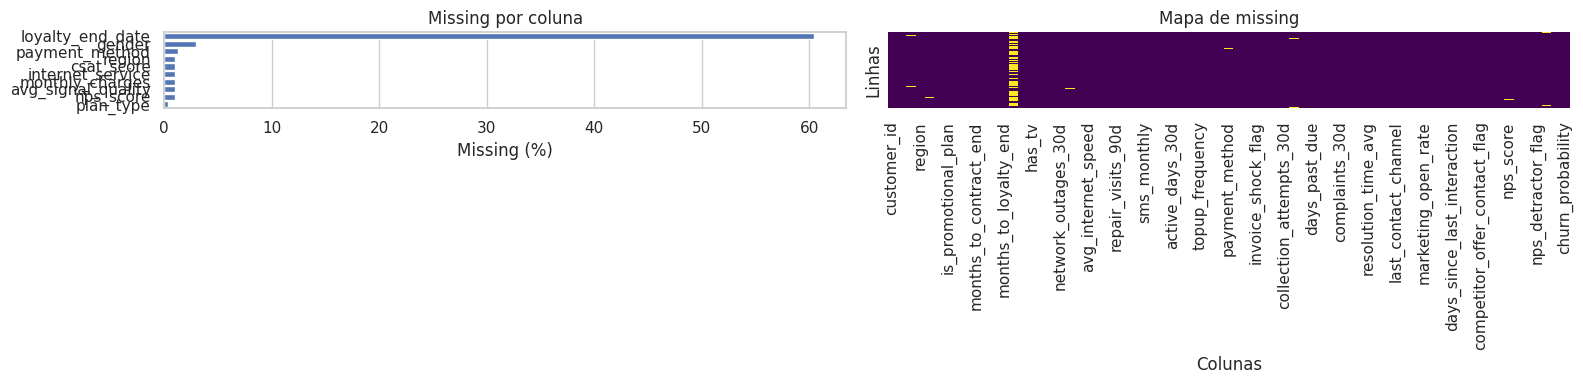

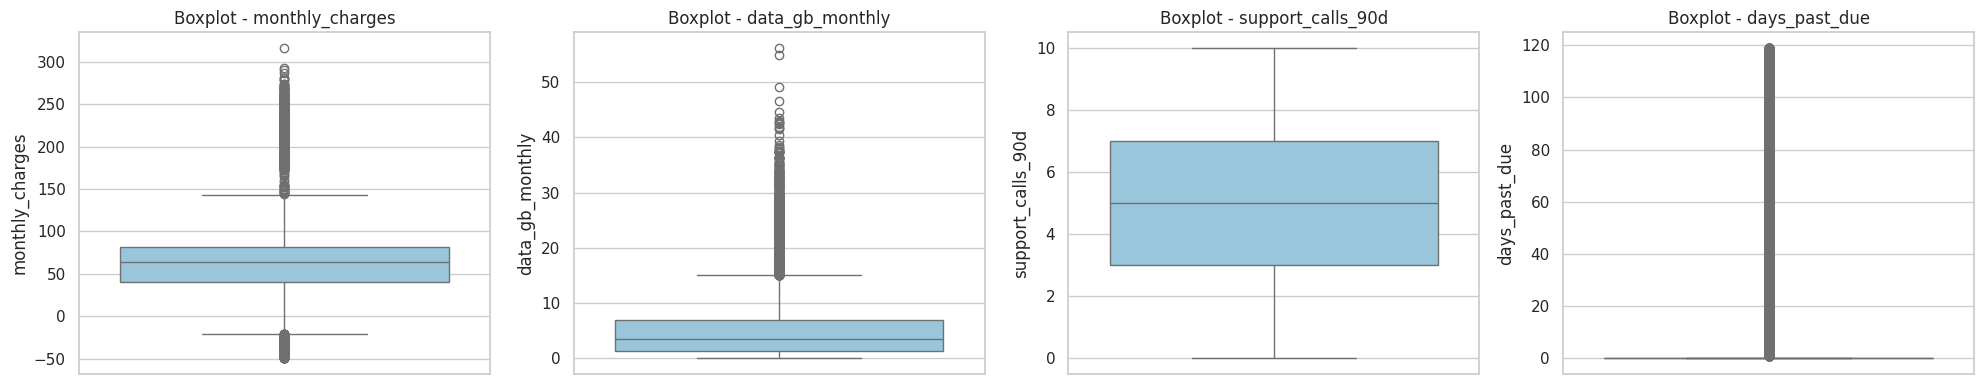

In [15]:
quality_flags = pd.DataFrame(
    {
        "check": [
            "IDs duplicados",
            "Linhas duplicadas",
            "Colunas constantes",
            "Colunas com missing",
            "Colunas com alta cardinalidade (>30%)",
        ],
        "resultado": [
            int(df[ID_COL].duplicated().sum()),
            int(df.duplicated().sum()),
            int((df.nunique(dropna=False) <= 1).sum()),
            int((df.isna().sum() > 0).sum()),
            int(((df.nunique(dropna=True) / len(df)) > 0.3).sum()),
        ],
    }
)
display(quality_flags)

missing_summary = (
    pd.DataFrame(
        {
            "coluna": df.columns,
            "missing": df.isna().sum().values,
            "missing_pct": (df.isna().mean() * 100).round(2).values,
        }
    )
    .query("missing > 0")
    .sort_values("missing_pct", ascending=False)
    .reset_index(drop=True)
)
display(missing_summary if not missing_summary.empty else pd.DataFrame({"status": ["Sem missing"]}))

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
if missing_summary.empty:
    axes[0].text(0.5, 0.5, "Sem valores ausentes", ha="center", va="center", fontsize=12)
    axes[0].set_axis_off()
else:
    sns.barplot(data=missing_summary, x="missing_pct", y="coluna", ax=axes[0], color="#4472c4")
    axes[0].set_title("Missing por coluna")
    axes[0].set_xlabel("Missing (%)")
    axes[0].set_ylabel("")

sns.heatmap(df.isna(), cbar=False, yticklabels=False, ax=axes[1], cmap="viridis")
axes[1].set_title("Mapa de missing")
axes[1].set_xlabel("Colunas")
axes[1].set_ylabel("Linhas")
plt.tight_layout()
plt.show()

outlier_cols = ["monthly_charges", "data_gb_monthly", "support_calls_90d", "days_past_due"]
outlier_cols = [c for c in outlier_cols if c in df.columns]

if outlier_cols:
    fig, axes = plt.subplots(1, len(outlier_cols), figsize=(5 * len(outlier_cols), 4))
    if len(outlier_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, outlier_cols):
        sns.boxplot(data=df, y=col, ax=ax, color="#8ecae6")
        ax.set_title(f"Boxplot - {col}")
    plt.tight_layout()
    plt.show()

### Identificacao quantitativa de outliers (Z-Score e IQR)

Complemento aos boxplots: calcula limites formais pelo metodo IQR (Tukey) e Z-Score para quantificar o volume de outliers por coluna numerica.

In [ ]:
numeric_cols_outlier = [
    c for c in df.select_dtypes(include="number").columns
    if c not in [TARGET_COL, ID_COL]
]

outlier_stats = []
for col in numeric_cols_outlier:
    series = df[col].dropna()
    if len(series) == 0:
        continue
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower_iqr = q1 - 1.5 * iqr
    upper_iqr = q3 + 1.5 * iqr
    n_iqr = int(((series < lower_iqr) | (series > upper_iqr)).sum())

    z_scores = (series - series.mean()) / series.std()
    n_zscore = int((z_scores.abs() > 3).sum())

    outlier_stats.append({
        "coluna": col,
        "q1": round(q1, 2),
        "q3": round(q3, 2),
        "iqr": round(iqr, 2),
        "lim_inf_iqr": round(lower_iqr, 2),
        "lim_sup_iqr": round(upper_iqr, 2),
        "n_outliers_iqr": n_iqr,
        "pct_outliers_iqr": round(n_iqr / len(series) * 100, 2),
        "n_outliers_zscore": n_zscore,
        "pct_outliers_zscore": round(n_zscore / len(series) * 100, 2),
    })

outlier_df = (
    pd.DataFrame(outlier_stats)
    .query("n_outliers_iqr > 0")
    .sort_values("pct_outliers_iqr", ascending=False)
    .reset_index(drop=True)
)

print(f"Colunas com outliers detectados pelo IQR: {len(outlier_df)}")
display(outlier_df)

## 3) Distribuicao do target e sinais de churn

Aqui olhamos se o target esta balanceado e quais grupos mostram risco relativo maior.

Nao e teste causal: e um diagnostico para orientar os baselines.

,churn,pct
0,0,60.69
1,1,39.31


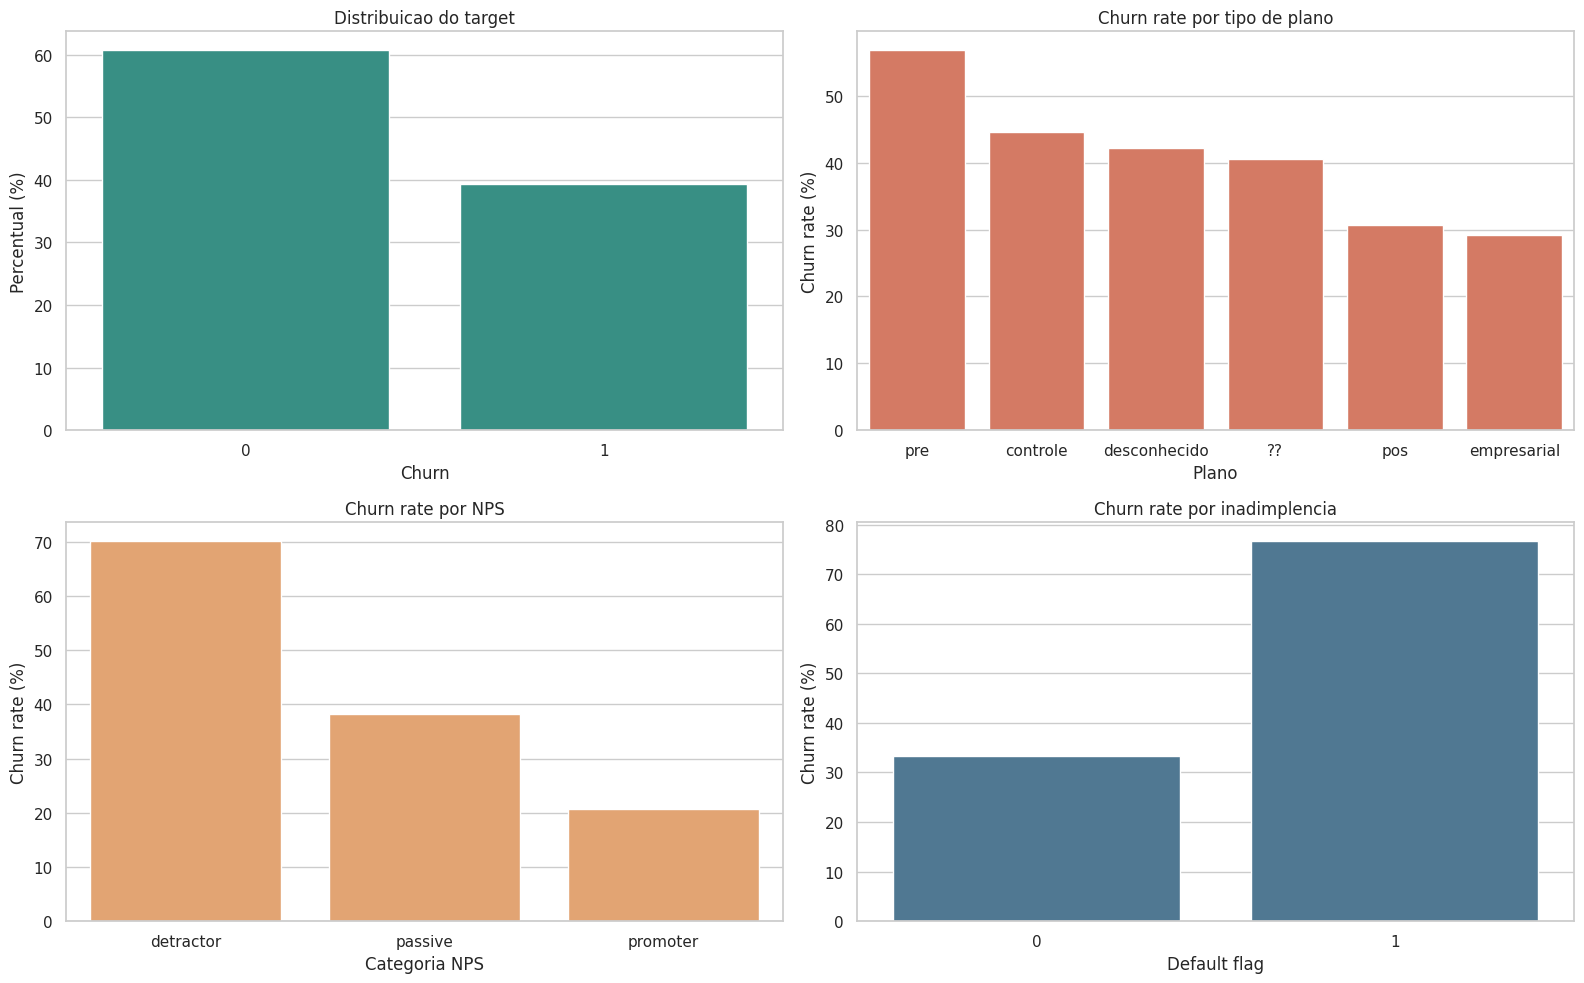

,plan_type,churn_rate,clientes
0,pre,56.80,10256
1,controle,44.53,12718
2,desconhecido,42.17,166
3,??,40.57,175
4,pos,30.75,22878
5,empresarial,29.13,5133


,nps_category,churn_rate,clientes
0,detractor,70.08,13244
1,passive,38.27,17294
2,promoter,20.73,20962


,default_flag,churn_rate,clientes
0,1,76.61,7075
1,0,33.37,44425


In [16]:
target_summary = (
    df[TARGET_COL]
    .value_counts(normalize=True)
    .rename_axis(TARGET_COL)
    .reset_index(name="pct")
)
target_summary["pct"] = target_summary["pct"] * 100
display(target_summary)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.barplot(data=target_summary, x=TARGET_COL, y="pct", ax=axes[0, 0], color="#2a9d8f")
axes[0, 0].set_title("Distribuicao do target")
axes[0, 0].set_xlabel("Churn")
axes[0, 0].set_ylabel("Percentual (%)")

plan_churn = (
    df.groupby("plan_type", observed=False)[TARGET_COL]
    .agg(churn_rate="mean", clientes="size")
    .sort_values("churn_rate", ascending=False)
    .reset_index()
)
plan_churn["churn_rate"] = plan_churn["churn_rate"] * 100
sns.barplot(data=plan_churn, x="plan_type", y="churn_rate", ax=axes[0, 1], color="#e76f51")
axes[0, 1].set_title("Churn rate por tipo de plano")
axes[0, 1].set_xlabel("Plano")
axes[0, 1].set_ylabel("Churn rate (%)")

nps_churn = (
    df.groupby("nps_category", observed=False)[TARGET_COL]
    .agg(churn_rate="mean", clientes="size")
    .sort_values("churn_rate", ascending=False)
    .reset_index()
)
nps_churn["churn_rate"] = nps_churn["churn_rate"] * 100
sns.barplot(data=nps_churn, x="nps_category", y="churn_rate", ax=axes[1, 0], color="#f4a261")
axes[1, 0].set_title("Churn rate por NPS")
axes[1, 0].set_xlabel("Categoria NPS")
axes[1, 0].set_ylabel("Churn rate (%)")

default_churn = (
    df.groupby("default_flag", observed=False)[TARGET_COL]
    .agg(churn_rate="mean", clientes="size")
    .sort_values("churn_rate", ascending=False)
    .reset_index()
)
default_churn["churn_rate"] = default_churn["churn_rate"] * 100
sns.barplot(data=default_churn, x="default_flag", y="churn_rate", ax=axes[1, 1], color="#457b9d")
axes[1, 1].set_title("Churn rate por inadimplencia")
axes[1, 1].set_xlabel("Default flag")
axes[1, 1].set_ylabel("Churn rate (%)")

plt.tight_layout()
plt.show()

display(plan_churn)
display(nps_churn)
display(default_churn)

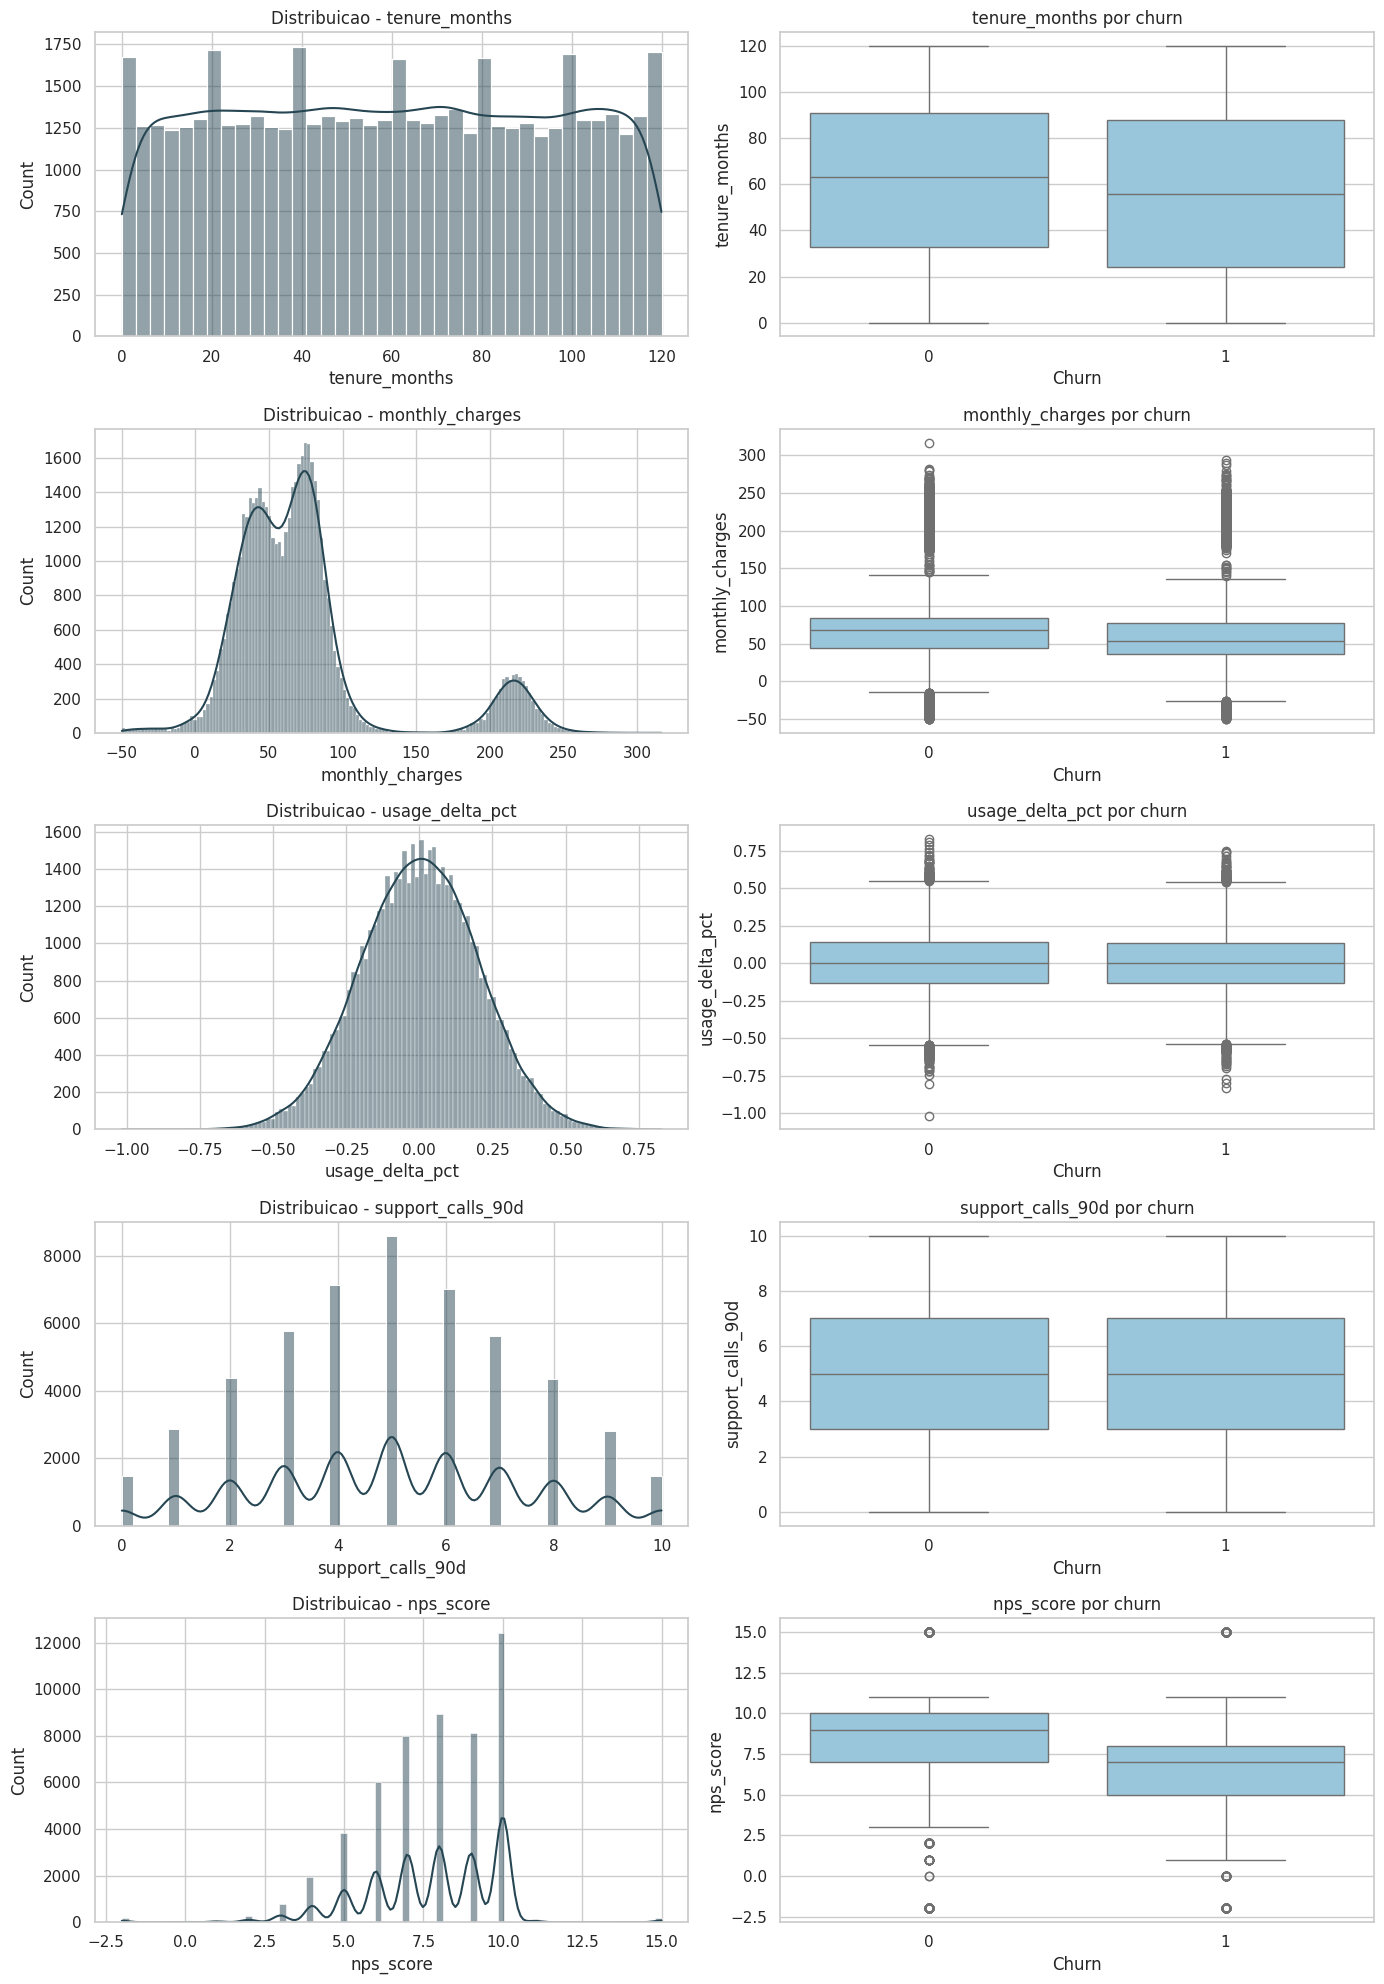

,feature,corr_com_churn
0,churn,1.00
1,churn_probability,0.69
2,nps_detractor_flag,0.37
3,default_flag,0.30
4,late_payments_6m,0.28
5,invoice_shock_flag,0.27
6,price_increase_last_3m,0.27
7,days_past_due,0.26
8,complaints_30d,0.11
9,days_since_last_interaction,0.09


,feature,corr_com_churn
46,discount_amount,-0.02
47,retention_offer_made,-0.02
48,retention_offer_accepted,-0.04
49,last_offer_accepted,-0.06
50,tenure_months,-0.07
51,months_to_loyalty_end,-0.08
52,has_loyalty,-0.10
53,avg_bill_last_6m,-0.12
54,monthly_charges,-0.12
55,avg_signal_quality,-0.12


In [17]:
selected_numeric = [
    "tenure_months",
    "monthly_charges",
    "usage_delta_pct",
    "support_calls_90d",
    "nps_score",
]
selected_numeric = [c for c in selected_numeric if c in df.columns]

fig, axes = plt.subplots(len(selected_numeric), 2, figsize=(14, 4 * len(selected_numeric)))
if len(selected_numeric) == 1:
    axes = [axes]

for idx, col in enumerate(selected_numeric):
    sns.histplot(data=df, x=col, kde=True, ax=axes[idx][0], color="#264653")
    axes[idx][0].set_title(f"Distribuicao - {col}")

    sns.boxplot(data=df, x=TARGET_COL, y=col, ax=axes[idx][1], color="#8ecae6")
    axes[idx][1].set_title(f"{col} por churn")
    axes[idx][1].set_xlabel("Churn")

plt.tight_layout()
plt.show()

corr_target = (
    df[feature_numeric_cols + [TARGET_COL]]
    .corr(numeric_only=True)[[TARGET_COL]]
    .sort_values(TARGET_COL, ascending=False)
    .reset_index()
    .rename(columns={"index": "feature", TARGET_COL: "corr_com_churn"})
)

display(corr_target.head(15))
display(corr_target.tail(15))

### Matriz de correlacao entre features (multicolinearidade)

Heatmap das correlacoes entre as variaveis numericas. Pares com correlacao alta (|r| > 0.7) indicam multicolinearidade — features que carregam informacao redundante e podem prejudicar modelos lineares.

In [ ]:
numeric_feat_cols = [
    c for c in df.select_dtypes(include="number").columns
    if c not in [TARGET_COL, ID_COL]
]

corr_matrix = df[numeric_feat_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(
    corr_matrix,
    annot=False,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.3,
    ax=ax,
)
ax.set_title("Matriz de correlacao entre features numericas", fontsize=14)
plt.tight_layout()
plt.show()

# Pares com alta correlacao (|r| > 0.7, excluindo diagonal)
high_corr_pairs = (
    corr_matrix.where(
        (corr_matrix.abs() > 0.7) & (corr_matrix != 1.0)
    )
    .stack()
    .reset_index()
    .rename(columns={"level_0": "feature_a", "level_1": "feature_b", 0: "correlacao"})
    .assign(correlacao=lambda x: x["correlacao"].round(3))
    .drop_duplicates(subset=["correlacao"])
    .sort_values("correlacao", ascending=False)
    .reset_index(drop=True)
)

if high_corr_pairs.empty:
    print("Nenhum par com |correlacao| > 0.7 encontrado.")
else:
    print(f"Pares com alta correlacao (|r| > 0.7): {len(high_corr_pairs)}")
    display(high_corr_pairs)

### Interpretacao da matriz de correlacao

A correlacao varia de **-1 a +1**:
- Proximo de **+1**: as duas features sobem juntas
- Proximo de **-1**: uma sobe quando a outra desce
- Proximo de **0**: sem relacao linear

Foram encontrados **14 pares com |r| > 0.7**, indicando redundancia de informacao. Os mais criticos (|r| > 0.9):

| Par | Correlacao | Interpretacao |
|---|---|---|
| `price_increase_last_3m` × `invoice_shock_flag` | 0.99 | Aumento de preco e flag de choque de fatura sao quase identicos — uma pode ser removida |
| `avg_bill_last_6m` × `monthly_charges` | 0.97 | Media historica e cobrança atual andam juntas — alta redundancia |
| `data_gb_monthly` × `avg_usage_last_3m` | 0.97 | Consumo atual e media recente sao proximos — redundancia de uso |
| `plan_price` × `avg_bill_last_6m` | 0.96 | Preco do plano determina a fatura — redundancia esperada |
| `plan_price` × `monthly_charges` | 0.94 | Mesma logica acima |
| `late_payments_6m` × `default_flag` | 0.92 | Historico de atraso e flag de inadimplencia derivam da mesma informacao |
| `is_promotional_plan` × `discount_amount` | 0.91 | Plano promocional implica desconto — redundancia logica |

Vale destacar tambem a correlacao negativa: `nps_score` × `nps_detractor_flag` = **-0.75** — quanto maior a satisfacao (NPS alto), menor a chance de ser detrator. Sao features derivadas uma da outra.

> **Implicacao para modelagem**: pares com |r| > 0.9 devem ter apenas uma das features mantida no modelo, especialmente para Regressao Logistica que e sensivel a multicolinearidade. Modelos baseados em arvore (Random Forest, XGBoost) sao menos afetados.

## 4) Data readiness e risco de leakage

Nesta secao, traduzimos EDA em regra de modelagem.

Perguntas chave:
- quais colunas podem entrar no baseline
- quais colunas devem ser removidas por leakage
- quais exigem governanca temporal

In [26]:
window_sensitive_cols = {
    "usage_delta_pct",
    "days_past_due",
    "support_calls_30d",
    "support_calls_90d",
    "complaints_30d",
    "tickets_open_30d",
    "days_since_last_usage",
    "days_since_last_interaction",
}

potential_leakage_cols = {
    "churn_probability",
    "retention_offer_accepted",
    "retention_offer_made",
}

duplicated_id_count = int(df[ID_COL].duplicated().sum())
duplicated_row_count = int(df.duplicated().sum())

readiness = pd.DataFrame(
    {
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "missing_pct": (df.isna().mean() * 100).round(2).values,
        "n_unique": df.nunique(dropna=True).values,
        "unique_ratio": (df.nunique(dropna=True) / len(df)).round(4).values,
    }
)
readiness["role"] = readiness["column"].map(
    lambda c: "id" if c == ID_COL else "target" if c == TARGET_COL else "feature"
)
readiness["constant"] = readiness["column"].map(lambda c: df[c].nunique(dropna=False) <= 1)
readiness["high_cardinality"] = readiness["unique_ratio"] > 0.3
readiness["window_sensitive"] = readiness["column"].isin(window_sensitive_cols)
readiness["potential_leakage"] = readiness["column"].isin(potential_leakage_cols)
readiness["recomendacao"] = readiness["column"].map(
    lambda c: (
        "remover do treino"
        if c == ID_COL
        else "excluir de features (sinal de leakage)"
        if c in potential_leakage_cols
        else "manter com governanca de janela temporal"
        if c in window_sensitive_cols
        else "ok para baseline"
    )
)

display(
    readiness.sort_values(
        ["potential_leakage", "window_sensitive", "missing_pct", "unique_ratio"],
        ascending=[False, False, False, False],
    )
)

readiness_checks = pd.DataFrame(
    [
        ["Volume para baseline", "OK", f"Base com {len(df):,} linhas e {df.shape[1]} colunas."],
        [
            "Qualidade estrutural (base bruta)",
            "ATENCAO",
            f"Base bruta tem {duplicated_row_count} linhas duplicadas e {duplicated_id_count} customer_id duplicados; tratar antes do treino.",
        ],
        ["Missing", "ATENCAO", "Missing relevante em loyalty_end_date e residual em variaveis categoricas e numericas."],
        ["Balanceamento do target", "OK", f"Churn em {df[TARGET_COL].mean():.2%}; adequado para baseline."],
        ["Leakage potencial", "ATENCAO", "Excluir churn_probability e colunas de retencao do treino."],
        ["Governanca temporal", "ATENCAO", "Definir janela de observacao para variaveis operacionais recentes."],
        [
            "Pronto para modelagem",
            "PARCIAL",
            "A base bruta nao esta pronta; precisa de tratamento, split sem leakage e validacao final antes do baseline.",
        ],
    ],
    columns=["check", "status", "observacao"],
)
display(readiness_checks)

,column,dtype,missing_pct,n_unique,unique_ratio,role,constant,high_cardinality,window_sensitive,potential_leakage,recomendacao
72,churn_probability,float64,0.00,496,0.01,feature,False,False,False,True,excluir de features (sinal de leakage)
64,retention_offer_made,int64,0.00,2,0.00,feature,False,False,False,True,excluir de features (sinal de leakage)
65,retention_offer_accepted,int64,0.00,2,0.00,feature,False,False,False,True,excluir de features (sinal de leakage)
28,usage_delta_pct,float64,0.00,1269,0.02,feature,False,False,True,False,manter com governanca de janela temporal
60,days_since_last_interaction,int64,0.00,180,0.00,feature,False,False,True,False,manter com governanca de janela temporal
...,...,...,...,...,...,...,...,...,...,...,...
61,portability_request_flag,int64,0.00,2,0.00,feature,False,False,False,False,ok para baseline
63,competitor_offer_contact_flag,int64,0.00,2,0.00,feature,False,False,False,False,ok para baseline
68,nps_promoter_flag,int64,0.00,2,0.00,feature,False,False,False,False,ok para baseline
69,nps_detractor_flag,int64,0.00,2,0.00,feature,False,False,False,False,ok para baseline


,check,status,observacao
0,Volume para baseline,OK,"Base com 51,500 linhas e 73 colunas."
1,Qualidade estrutural (base bruta),ATENCAO,Base bruta tem 1178 linhas duplicadas e 2451 c...
2,Missing,ATENCAO,Missing relevante em loyalty_end_date e residu...
3,Balanceamento do target,OK,Churn em 39.31%; adequado para baseline.
4,Leakage potencial,ATENCAO,Excluir churn_probability e colunas de retenca...
5,Governanca temporal,ATENCAO,Definir janela de observacao para variaveis op...
6,Pronto para modelagem,PARCIAL,A base bruta nao esta pronta; precisa de trata...


## 5) Tratamento da base para baseline

Ate a secao anterior, a leitura foi feita sobre a **base bruta**, justamente para diagnosticar os problemas de qualidade e risco metodologico.

A partir daqui, o objetivo passa a ser preparo minimo para modelagem.

Regras adotadas nesta Fase 1:
- auditar duplicidades exatas e IDs repetidos antes de remover registros
- corrigir valores invalidos obvios, convertendo para `NaN` quando necessario
- ajustar inconsistencias logicas simples
- separar treino e teste antes de imputacao e encoding
- ajustar estatisticas de imputacao apenas no treino
- aplicar one-hot encoding com alinhamento de colunas entre treino e teste

Essas escolhas sao simples, reproduziveis e adequadas para baseline.

In [27]:
df_model = df.copy()

linhas_iniciais = len(df_model)
duplicadas_iniciais = int(df_model.duplicated().sum())
ids_duplicados_iniciais = int(df_model[ID_COL].duplicated().sum())

duplicate_id_mask = df_model[ID_COL].duplicated(keep=False)
duplicate_id_rows = df_model.loc[duplicate_id_mask, [ID_COL, TARGET_COL]].copy()

if duplicate_id_rows.empty:
    duplicate_id_audit = pd.DataFrame(
        [
            {"metrica": "customer_id_duplicados", "valor": 0},
            {"metrica": "linhas_em_ids_duplicados", "valor": 0},
            {"metrica": "ids_com_conflito_no_target", "valor": 0},
            {"metrica": "maior_qtd_registros_por_id", "valor": 1},
            {"metrica": "regra_adotada", "valor": "sem duplicados por ID"},
        ]
    )
else:
    duplicate_id_groups = (
        duplicate_id_rows.groupby(ID_COL)
        .agg(registros=(ID_COL, "size"), churn_nunique=(TARGET_COL, "nunique"))
        .reset_index()
    )
    duplicate_id_audit = pd.DataFrame(
        [
            {"metrica": "customer_id_duplicados", "valor": int(duplicate_id_groups.shape[0])},
            {"metrica": "linhas_em_ids_duplicados", "valor": int(duplicate_id_rows.shape[0])},
            {"metrica": "ids_com_conflito_no_target", "valor": int((duplicate_id_groups["churn_nunique"] > 1).sum())},
            {"metrica": "maior_qtd_registros_por_id", "valor": int(duplicate_id_groups["registros"].max())},
            {
                "metrica": "regra_adotada",
                "valor": "remover duplicidade exata e depois manter primeira ocorrencia por customer_id",
            },
        ]
    )

df_model = df_model.drop_duplicates().copy()
df_model = df_model.drop_duplicates(subset=[ID_COL], keep="first").copy()

correcoes = []

def invalid_to_nan(frame, column, condition, descricao):
    if column not in frame.columns:
        return
    count = int(condition.fillna(False).sum())
    if count > 0:
        frame.loc[condition, column] = np.nan
    correcoes.append({"regra": descricao, "linhas_afetadas": count})

invalid_to_nan(df_model, "age", ~df_model["age"].between(18, 100), "idade fora da faixa 18-100")
invalid_to_nan(df_model, "monthly_charges", df_model["monthly_charges"] < 0, "monthly_charges negativo")
invalid_to_nan(df_model, "avg_signal_quality", ~df_model["avg_signal_quality"].between(0, 5), "avg_signal_quality fora da faixa 0-5")
invalid_to_nan(df_model, "call_drop_rate", ~df_model["call_drop_rate"].between(0, 1), "call_drop_rate fora da faixa 0-1")
invalid_to_nan(df_model, "nps_score", ~df_model["nps_score"].between(0, 10), "nps_score fora da faixa 0-10")
invalid_to_nan(df_model, "csat_score", ~df_model["csat_score"].between(1, 5), "csat_score fora da faixa 1-5")
invalid_to_nan(df_model, "tenure_months", ~df_model["tenure_months"].between(0, 120), "tenure_months fora da faixa 0-120")
invalid_to_nan(df_model, "months_to_contract_end", ~df_model["months_to_contract_end"].between(0, 36), "months_to_contract_end fora da faixa 0-36")
invalid_to_nan(df_model, "months_to_loyalty_end", ~df_model["months_to_loyalty_end"].between(0, 24), "months_to_loyalty_end fora da faixa 0-24")

valid_categories = {
    "plan_type": {"pre", "controle", "pos", "empresarial"},
    "payment_method": {"card", "boleto", "debito", "pix"},
    "internet_service": {"dsl", "fiber", "none"},
    "billing_type": {"digital", "paper", "auto"},
    "nps_category": {"promoter", "passive", "detractor"},
}

for column, valid_values in valid_categories.items():
    if column in df_model.columns:
        invalid_mask = ~df_model[column].isin(valid_values) & df_model[column].notna()
        invalid_to_nan(df_model, column, invalid_mask, f"categoria invalida em {column}")

if {"has_loyalty", "months_to_loyalty_end"}.issubset(df_model.columns):
    mask = (df_model["has_loyalty"] == 0) & (df_model["months_to_loyalty_end"] > 0)
    count = int(mask.sum())
    if count > 0:
        df_model.loc[mask, "months_to_loyalty_end"] = 0
        if "loyalty_end_date" in df_model.columns:
            df_model.loc[mask, "loyalty_end_date"] = pd.NaT
    correcoes.append({"regra": "ajuste de fidelidade inconsistente", "linhas_afetadas": count})

if {"default_flag", "days_past_due"}.issubset(df_model.columns):
    mask = (df_model["default_flag"] == 0) & (df_model["days_past_due"] > 0)
    count = int(mask.sum())
    if count > 0:
        df_model.loc[mask, "default_flag"] = 1
    correcoes.append({"regra": "default_flag ajustado quando havia atraso", "linhas_afetadas": count})

if {"retention_offer_made", "retention_offer_accepted"}.issubset(df_model.columns):
    mask = (df_model["retention_offer_accepted"] == 1) & (df_model["retention_offer_made"] == 0)
    count = int(mask.sum())
    if count > 0:
        df_model.loc[mask, "retention_offer_made"] = 1
    correcoes.append({"regra": "retention_offer_made ajustado quando oferta foi aceita", "linhas_afetadas": count})

tratamento_resumo = pd.DataFrame(
    [
        {"etapa": "linhas_iniciais", "valor": linhas_iniciais},
        {"etapa": "duplicadas_iniciais", "valor": duplicadas_iniciais},
        {"etapa": "ids_duplicados_iniciais", "valor": ids_duplicados_iniciais},
        {"etapa": "linhas_pos_duplicidade", "valor": len(df_model)},
    ]
)
display(duplicate_id_audit)
display(tratamento_resumo)
display(pd.DataFrame(correcoes).query("linhas_afetadas > 0"))

,metrica,valor
0,customer_id_duplicados,2370
1,linhas_em_ids_duplicados,4821
2,ids_com_conflito_no_target,497
3,maior_qtd_registros_por_id,4
4,regra_adotada,remover duplicidade exata e depois manter prim...


,etapa,valor
0,linhas_iniciais,51500
1,duplicadas_iniciais,1178
2,ids_duplicados_iniciais,2451
3,linhas_pos_duplicidade,49049


,regra,linhas_afetadas
0,idade fora da faixa 18-100,495
1,monthly_charges negativo,727
2,avg_signal_quality fora da faixa 0-5,982
3,call_drop_rate fora da faixa 0-1,495
4,nps_score fora da faixa 0-10,980
5,csat_score fora da faixa 1-5,478
9,categoria invalida em plan_type,325
10,categoria invalida em payment_method,322
14,ajuste de fidelidade inconsistente,495
15,default_flag ajustado quando havia atraso,495


## 6) Split, imputacao e matriz final sem leakage

Com a base corrigida, montamos a matriz final para baseline sem contaminar treino com informacao do teste.

Escolhas desta etapa:
- exclusao de colunas com leakage e identificadores
- exclusao de datas brutas redundantes
- split estratificado em 80% treino e 20% teste antes de qualquer transformacao
- imputacao com mediana para numericas, ajustada no treino
- imputacao com moda para categoricas, ajustada no treino
- one-hot encoding com `pd.get_dummies()` e alinhamento do teste pelas colunas do treino

In [ ]:
drop_cols = [
    ID_COL,
    TARGET_COL,
    "churn_probability",
    "retention_offer_made",
    "retention_offer_accepted",
    "contract_renewal_date",
    "loyalty_end_date",
]
drop_cols = [col for col in drop_cols if col in df_model.columns]

X_raw = df_model.drop(columns=drop_cols).copy()
y = df_model[TARGET_COL].copy()

def stratified_split(features, target, test_size=0.20, random_state=42):
    rng = np.random.default_rng(random_state)
    test_idx = []
    for class_value in sorted(target.unique()):
        class_index = target[target == class_value].index.to_numpy()
        n_test = max(1, int(round(len(class_index) * test_size)))
        selected = rng.choice(class_index, size=n_test, replace=False)
        test_idx.extend(selected.tolist())
    test_idx = pd.Index(sorted(test_idx))
    train_idx = features.index.difference(test_idx)
    return (
        features.loc[train_idx].copy(),
        features.loc[test_idx].copy(),
        target.loc[train_idx].copy(),
        target.loc[test_idx].copy(),
    )

X_train_raw, X_test_raw, y_train, y_test = stratified_split(
    X_raw,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

numeric_model_cols = X_train_raw.select_dtypes(include="number").columns.tolist()
categorical_model_cols = X_train_raw.select_dtypes(exclude="number").columns.tolist()

train_numeric_fill = X_train_raw[numeric_model_cols].median() if numeric_model_cols else pd.Series(dtype=float)
train_categorical_fill = {}
for col in categorical_model_cols:
    mode = X_train_raw[col].mode(dropna=True)
    train_categorical_fill[col] = mode.iloc[0] if not mode.empty else "desconhecido"

X_train_prepared = X_train_raw.copy()
X_test_prepared = X_test_raw.copy()

if numeric_model_cols:
    X_train_prepared[numeric_model_cols] = X_train_prepared[numeric_model_cols].fillna(train_numeric_fill)
    X_test_prepared[numeric_model_cols] = X_test_prepared[numeric_model_cols].fillna(train_numeric_fill)

for col, fill_value in train_categorical_fill.items():
    X_train_prepared[col] = X_train_prepared[col].fillna(fill_value)
    X_test_prepared[col] = X_test_prepared[col].fillna(fill_value)

# Capping de outliers por IQR — limites calculados APENAS no treino e aplicados em treino e teste
# Colunas com IQR = 0 sao ignoradas (maioria dos valores identicos; capping tornaria a coluna constante)
COLS_TO_CAP = [
    c for c in ["monthly_charges", "data_gb_monthly", "support_calls_90d", "days_past_due"]
    if c in X_train_prepared.columns
]
cap_log = []
for col in COLS_TO_CAP:
    series = X_train_prepared[col].dropna()
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        cap_log.append({
            "coluna": col,
            "lim_inf": None,
            "lim_sup": None,
            "linhas_corrigidas_treino": 0,
            "linhas_corrigidas_teste": 0,
            "observacao": "IQR=0, capping ignorado",
        })
        continue
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_train = int(((X_train_prepared[col] < lower) | (X_train_prepared[col] > upper)).sum())
    n_test = int(((X_test_prepared[col] < lower) | (X_test_prepared[col] > upper)).sum())
    X_train_prepared[col] = X_train_prepared[col].clip(lower=lower, upper=upper)
    X_test_prepared[col] = X_test_prepared[col].clip(lower=lower, upper=upper)
    cap_log.append({
        "coluna": col,
        "lim_inf": round(lower, 2),
        "lim_sup": round(upper, 2),
        "linhas_corrigidas_treino": n_train,
        "linhas_corrigidas_teste": n_test,
        "observacao": "capping aplicado",
    })
display(pd.DataFrame(cap_log))

X_train = pd.get_dummies(
    X_train_prepared,
    columns=categorical_model_cols,
    drop_first=False,
    dtype=int,
)
X_test = pd.get_dummies(
    X_test_prepared,
    columns=categorical_model_cols,
    drop_first=False,
    dtype=int,
)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

prepared_summary = pd.DataFrame(
    [
        {"metrica": "linhas_modelagem", "valor": len(X_raw)},
        {"metrica": "features_pos_one_hot", "valor": X_train.shape[1]},
        {"metrica": "linhas_treino", "valor": len(X_train)},
        {"metrica": "linhas_teste", "valor": len(X_test)},
        {"metrica": "pct_teste", "valor": round(TEST_SIZE * 100, 2)},
        {"metrica": "churn_treino", "valor": round(y_train.mean() * 100, 2)},
        {"metrica": "churn_teste", "valor": round(y_test.mean() * 100, 2)},
    ]
)
display(prepared_summary)

display(X_train.head(3))

## 7) Validacao final da base preparada

Esta secao separa explicitamente a leitura da base bruta da verificacao da base pronta para baseline.

Checklist final:
- nao restaram duplicidades estruturais apos o tratamento
- treino e teste nao possuem missing apos imputacao
- colunas de leakage ficaram fora da matriz final
- o split preservou o balanceamento do target
- nao surgiram colunas constantes inesperadas na matriz de treino

In [29]:
post_treatment_checks = pd.DataFrame(
    [
        {"check": "IDs duplicados apos tratamento", "valor": int(df_model[ID_COL].duplicated().sum())},
        {"check": "Linhas duplicadas apos tratamento", "valor": int(df_model.duplicated().sum())},
        {"check": "Missing totais no treino", "valor": int(X_train.isna().sum().sum())},
        {"check": "Missing totais no teste", "valor": int(X_test.isna().sum().sum())},
        {
            "check": "Colunas de leakage presentes na matriz final",
            "valor": int(
                sum(
                    col in X_train.columns
                    for col in potential_leakage_cols.union({ID_COL, TARGET_COL, "contract_renewal_date", "loyalty_end_date"})
                )
            ),
        },
        {"check": "Colunas constantes no treino", "valor": int((X_train.nunique(dropna=False) <= 1).sum())},
    ]
)
post_treatment_checks["status"] = post_treatment_checks["valor"].map(lambda value: "OK" if value == 0 else "ATENCAO")

target_preservation = pd.DataFrame(
    [
        {"base": "base_bruta", "churn_pct": round(df[TARGET_COL].mean() * 100, 2), "linhas": len(df)},
        {"base": "base_tratada", "churn_pct": round(df_model[TARGET_COL].mean() * 100, 2), "linhas": len(df_model)},
        {"base": "treino", "churn_pct": round(y_train.mean() * 100, 2), "linhas": len(y_train)},
        {"base": "teste", "churn_pct": round(y_test.mean() * 100, 2), "linhas": len(y_test)},
    ]
)

display(post_treatment_checks)
display(target_preservation)

,check,valor,status
0,IDs duplicados apos tratamento,0,OK
1,Linhas duplicadas apos tratamento,0,OK
2,Missing totais no treino,0,OK
3,Missing totais no teste,0,OK
4,Colunas de leakage presentes na matriz final,0,OK
5,Colunas constantes no treino,0,OK


,base,churn_pct,linhas
0,base_bruta,39.31,51500
1,base_tratada,39.36,49049
2,treino,39.36,39239
3,teste,39.37,9810


## 8) Conclusao executiva

A base estendida e util para o problema de churn porque combina sinais de perfil, uso, pagamento, experiencia e relacionamento.

A Fase 1 foi conduzida seguindo o fluxo CRISP-DM, partindo do entendimento do negocio ate a entrega de uma matriz pronta para modelagem:

- o problema foi definido com objetivo, stakeholders, metricas de sucesso e custo do erro (secao 0)
- a leitura da base bruta revelou problemas reais de qualidade: duplicidades, missing, valores fora de faixa e inconsistencias logicas
- outliers foram identificados quantitativamente via IQR e Z-Score (secao 2) e tratados com capping nos limites do IQR (secao 6)
- colunas com risco de leakage foram mapeadas e excluidas da modelagem
- treino e teste foram separados antes de qualquer transformacao
- imputacao (mediana/moda) e capping foram fitados apenas no treino e aplicados no teste, sem contaminacao
- a matriz final passou por validacao objetiva

Ao final desta etapa, a base fica pronta para a proxima fase: comparar modelos baseline com avaliacao consistente em treino e teste.